# **Job Scam Detection — SBERT + Random Forest (v2)**

## **Install Dependencies**

In [ ]:
!pip install -q sentence-transformers scikit-learn imbalanced-learn matplotlib seaborn nltk kagglehub joblib

In [ ]:
import os, re, json, shutil, sys
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import nltk
import sklearn
import kagglehub

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, average_precision_score,
    f1_score, accuracy_score, precision_score, recall_score,
    matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sentence_transformers import SentenceTransformer

for pkg in ["punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

OUT_DIR = "model2_sbert_rf"
os.makedirs(OUT_DIR, exist_ok=True)

print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.6.1


## **Shared Preprocessing**

In [ ]:
scam_features_src = r'''
import re
from typing import List

import numpy as np
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

_lemmatizer = WordNetLemmatizer()
_stop_words = set(stopwords.words("english"))

URGENT_KEYWORDS: List[str] = [
    "urgent", "immediate", "asap", "hurry", "quick", "fast", "now",
]
HIGH_PAY_KEYWORDS: List[str] = [
    "high pay", "high salary", "earn money", "make money", "cash",
    "guaranteed income", "unlimited earning",
]
LOW_SKILL_KEYWORDS: List[str] = [
    "no experience", "no skill", "easy", "simple", "anyone can",
]
SUSPICIOUS_KEYWORDS: List[str] = [
    "work from home", "wfh", "limited time", "apply now", "free",
    "bonus", "prize", "winner",
]
TELECOMMUTE_KEYWORDS: List[str] = [
    "work from home", "wfh", "remote", "telecommute", "home based", "work anywhere",
]

FEATURE_NAMES: List[str] = [
    "text_length", "word_count", "urgent_count", "high_pay_count",
    "low_skill_count", "suspicious_count", "telecommuting", "has_questions",
]


def combine(title: str, description: str) -> str:
    return f"{title or ''} {description or ''}".strip()


def clean_text(text: str) -> str:
    if text is None:
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [_lemmatizer.lemmatize(w) for w in tokens
              if w not in _stop_words and len(w) > 2]
    return " ".join(tokens)


def _count(text_lower: str, keywords: List[str]) -> int:
    return sum(1 for kw in keywords
               if re.search(rf"\b{re.escape(kw)}\b", text_lower))


def engineered_features(combined: str, cleaned: str) -> np.ndarray:
    low = combined.lower()
    return np.array([
        float(len(combined)),
        float(len(cleaned.split())),
        float(_count(low, URGENT_KEYWORDS)),
        float(_count(low, HIGH_PAY_KEYWORDS)),
        float(_count(low, LOW_SKILL_KEYWORDS)),
        float(_count(low, SUSPICIOUS_KEYWORDS)),
        1.0 if _count(low, TELECOMMUTE_KEYWORDS) else 0.0,
        1.0 if "?" in combined else 0.0,
    ], dtype=np.float64)


def build_row(title: str, description: str, encoder) -> np.ndarray:
    combined = combine(title, description)
    cleaned = clean_text(combined)
    emb = encoder.encode([cleaned], show_progress_bar=False)[0]
    return np.concatenate([emb, engineered_features(combined, cleaned)])
'''

with open(f"{OUT_DIR}/scam_features.py", "w") as f:
    f.write(scam_features_src)

sys.path.insert(0, OUT_DIR)
import scam_features
import importlib
importlib.reload(scam_features)

print(len(scam_features.FEATURE_NAMES), "engineered features")

8 engineered features


## **Dataset**

In [ ]:
path = kagglehub.dataset_download("amruthjithrajvr/recruitment-scam")
csv_files = [os.path.join(root, f)
             for root, _, files in os.walk(path) for f in files if f.endswith(".csv")]
df = pd.read_csv(csv_files[0])

if df["fraudulent"].dtype == "object":
    df["fraudulent"] = df["fraudulent"].map({"t": 1, "f": 0}).fillna(0).astype(int)

print(f"Total samples : {len(df)}")
print(f"Fraudulent    : {df['fraudulent'].sum()} ({df['fraudulent'].mean()*100:.2f}%)")
print(f"Legitimate    : {len(df)-df['fraudulent'].sum()}")

100%|██████████| 17.8M/17.8M [00:00<00:00, 49.1MB/s]

Extracting files...


Total samples : 17880
Fraudulent    : 866 (4.84%)
Legitimate    : 17014


## **Preprocessing**

In [ ]:
for col in ["title", "description"]:
    df[col] = df[col].fillna("")

df["combined_text"] = [scam_features.combine(t, d)
                       for t, d in zip(df["title"], df["description"])]
df["cleaned_text"] = df["combined_text"].apply(scam_features.clean_text)
df = df[df["cleaned_text"].str.strip() != ""].reset_index(drop=True)

print(f"samples: {len(df)}")
print(df["combined_text"].str.len().describe().round(1).to_string())

samples: 17880
count    17880.0
mean      1468.1
std       1715.1
min         25.0
25%        706.0
50%       1186.0
75%       1804.0
max      55157.0


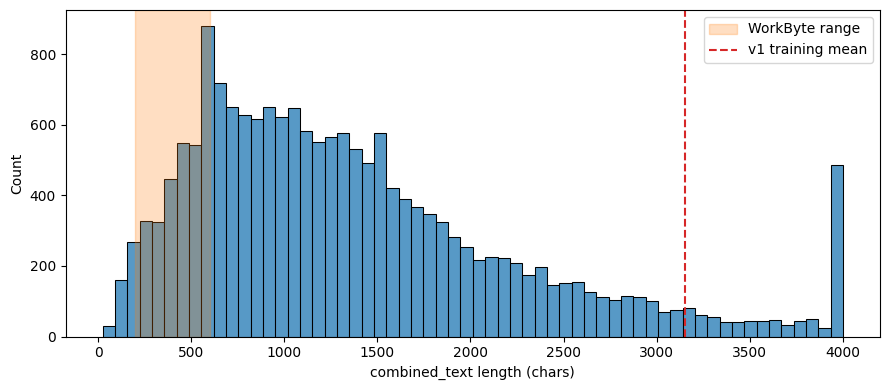

In [ ]:
plt.figure(figsize=(9, 4))
sns.histplot(df["combined_text"].str.len().clip(upper=4000), bins=60)
plt.axvspan(200, 600, color="tab:orange", alpha=0.25, label="WorkByte range")
plt.axvline(3153, color="tab:red", ls="--", label="v1 training mean")
plt.xlabel("combined_text length (chars)")
plt.legend()
plt.tight_layout()
plt.show()

## **Features**

In [ ]:
sbert_model_name = "BAAI/bge-base-en-v1.5"
sbert_model = SentenceTransformer(sbert_model_name)

embeddings = sbert_model.encode(
    df["cleaned_text"].tolist(), show_progress_bar=True, batch_size=64
)

X_eng = np.vstack([
    scam_features.engineered_features(c, cl)
    for c, cl in zip(df["combined_text"], df["cleaned_text"])
])

X = np.hstack([embeddings, X_eng])
y = df["fraudulent"].values

print(f"feature matrix: {X.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/280 [00:00<?, ?it/s]

feature matrix: (17880, 776)


## **Split**

In [ ]:
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:<6} n={len(yy):<6} scam={yy.sum():<5} ({yy.mean()*100:.2f}%)")

train  n=10728  scam=520   (4.85%)
val    n=3576   scam=173   (4.84%)
test   n=3576   scam=173   (4.84%)


## **Training Data**

In [ ]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_s, y_train)

rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=25, min_samples_split=5, min_samples_leaf=2,
    max_features="sqrt", random_state=42, n_jobs=-1,
)
rf_model.fit(X_train_bal, y_train_bal)

print(f"after SMOTE: {len(y_train_bal)}")
print("training completed")

after SMOTE: 20416
training completed


## **Calibration**

In [ ]:
val_raw = rf_model.predict_proba(X_val_s)[:, 1]

calibrator = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
calibrator.fit(val_raw, y_val)

def predict_calibrated(X_scaled):
    return calibrator.predict(rf_model.predict_proba(X_scaled)[:, 1])

val_cal  = predict_calibrated(X_val_s)
test_raw = rf_model.predict_proba(X_test_s)[:, 1]
test_cal = predict_calibrated(X_test_s)

print(f"{'':<14}{'raw':>20}{'calibrated':>20}")
print(f"{'range':<14}{f'{test_raw.min():.3f} - {test_raw.max():.3f}':>20}"
      f"{f'{test_cal.min():.3f} - {test_cal.max():.3f}':>20}")
print(f"{'AUC-ROC':<14}{roc_auc_score(y_test, test_raw):>20.4f}"
      f"{roc_auc_score(y_test, test_cal):>20.4f}")
print(f"{'avg precision':<14}{average_precision_score(y_test, test_raw):>20.4f}"
      f"{average_precision_score(y_test, test_cal):>20.4f}")

                               raw          calibrated
range                0.000 - 0.995       0.000 - 1.000
AUC-ROC                     0.9640              0.9634
avg precision               0.7927              0.7587


## **Calibrator Resolution**

In [ ]:
levels = np.unique(np.round(calibrator.predict(np.linspace(0, 1, 2001)), 6))

print(f"distinct output levels: {len(levels)}")
print(f"lowest 12 : {np.round(levels[:12], 4).tolist()}")
print(f"highest 6 : {np.round(levels[-6:], 4).tolist()}")

gaps = np.diff(levels)
print(f"widest gap: {gaps.max():.4f} between {levels[gaps.argmax()]:.4f} "
      f"and {levels[gaps.argmax()+1]:.4f}")

distinct output levels: 76
lowest 12 : [0.0, 0.0016, 0.0024, 0.0033, 0.0113, 0.0349, 0.0357, 0.0369, 0.0494, 0.05, 0.1, 0.1163]
highest 6 : [0.9802, 0.9846, 0.9889, 0.9933, 0.9976, 1.0]
widest gap: 0.0765 between 0.2500 and 0.3265


## **Thresholds**

In [ ]:
MAX_SOFT_FLAG_RATE = 0.15
MIN_AUTO_REMOVE_PRECISION = 0.95
MIN_SOFT_FLAG_RECALL = 0.90

observed = np.unique(val_cal)
bounds = np.unique(np.concatenate([[0.0], observed, [1.0]]))
gaps = np.unique(np.round((bounds[:-1] + bounds[1:]) / 2, 4))

rows = []
for t in gaps:
    pred = (val_cal >= t).astype(int)
    rows.append({
        "threshold": float(t),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall":    recall_score(y_val, pred, zero_division=0),
        "f1":        f1_score(y_val, pred, zero_division=0),
        "flag_rate": float(pred.mean()),
    })
sweep = pd.DataFrame(rows)

HARD_FLAG = float(sweep.loc[sweep["f1"].idxmax(), "threshold"])

below = sweep[sweep["threshold"] < HARD_FLAG]
soft_pool = below[(below["recall"] >= MIN_SOFT_FLAG_RECALL)
                  & (below["flag_rate"] <= MAX_SOFT_FLAG_RATE)]
if len(soft_pool) == 0:
    soft_pool = below[below["flag_rate"] <= MAX_SOFT_FLAG_RATE]
SOFT_FLAG = float(soft_pool["threshold"].min()) if len(soft_pool) else float(below["threshold"].max())

above = sweep[sweep["threshold"] > HARD_FLAG]
auto_pool = above[above["precision"] >= MIN_AUTO_REMOVE_PRECISION]
if len(auto_pool) == 0:
    auto_pool = above
AUTO_REMOVE = float(auto_pool["threshold"].min()) if len(auto_pool) else 1.0

assert SOFT_FLAG < HARD_FLAG < AUTO_REMOVE, (SOFT_FLAG, HARD_FLAG, AUTO_REMOVE)

print(f"{'name':<13}{'value':>9}{'precision':>11}{'recall':>9}{'f1':>8}{'flag rate':>11}")
for name, t in [("SOFT_FLAG", SOFT_FLAG), ("HARD_FLAG", HARD_FLAG), ("AUTO_REMOVE", AUTO_REMOVE)]:
    r = sweep[sweep["threshold"] == t].iloc[0]
    print(f"{name:<13}{t:>9.4f}{r.precision:>11.4f}{r.recall:>9.4f}"
          f"{r.f1:>8.4f}{r.flag_rate:>11.2%}")

name             value  precision   recall      f1  flag rate
SOFT_FLAG       0.0353     0.3876   0.8671  0.5357     10.82%
HARD_FLAG       0.4633     0.9068   0.6185  0.7354      3.30%
AUTO_REMOVE     0.6750     0.9694   0.5491  0.7011      2.74%


In [ ]:
print(f"{'threshold':>10}{'flagged':>9}{'rate':>9}")
for t in (0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90):
    pred = (val_cal >= t)
    print(f"{t:>10.2f}{int(pred.sum()):>9}{pred.mean():>9.2%}")

 threshold  flagged     rate
      0.01     1380   38.59%
      0.02      760   21.25%
      0.03      760   21.25%
      0.05      359   10.04%
      0.10      339    9.48%
      0.20      180    5.03%
      0.30      167    4.67%
      0.50      118    3.30%
      0.70       98    2.74%
      0.90       90    2.52%


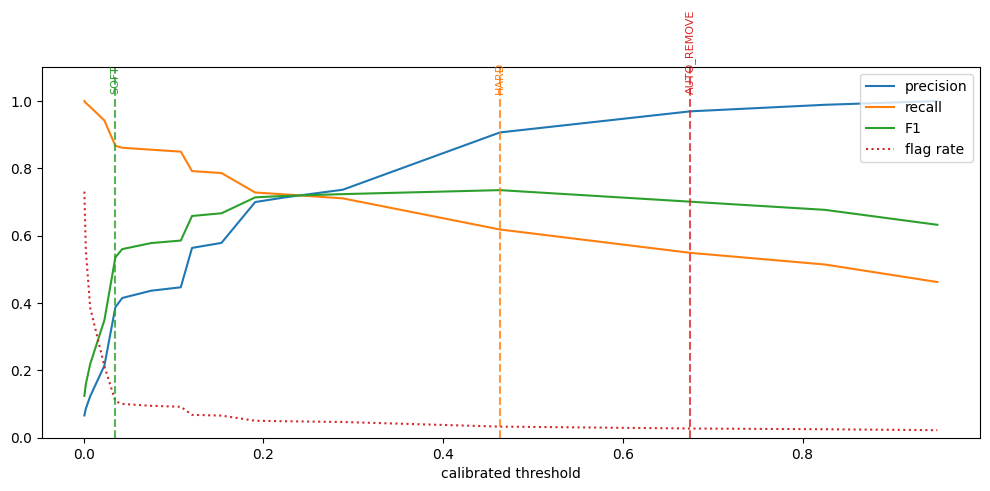

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep["threshold"], sweep["precision"], label="precision")
ax.plot(sweep["threshold"], sweep["recall"], label="recall")
ax.plot(sweep["threshold"], sweep["f1"], label="F1")
ax.plot(sweep["threshold"], sweep["flag_rate"], label="flag rate", ls=":")
for name, t, c in [("SOFT", SOFT_FLAG, "tab:green"),
                   ("HARD", HARD_FLAG, "tab:orange"),
                   ("AUTO_REMOVE", AUTO_REMOVE, "tab:red")]:
    ax.axvline(t, ls="--", color=c, alpha=0.8)
    ax.text(t, 1.02, name, rotation=90, va="bottom", ha="center", fontsize=8, color=c)
ax.set_xlabel("calibrated threshold")
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

## **Evaluation**

In [ ]:
y_pred = (test_cal >= HARD_FLAG).astype(int)

accuracy     = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision    = precision_score(y_test, y_pred, zero_division=0)
recall       = recall_score(y_test, y_pred, zero_division=0)
f1           = f1_score(y_test, y_pred, zero_division=0)
auc          = roc_auc_score(y_test, test_cal)
ap           = average_precision_score(y_test, test_cal)
mcc          = matthews_corrcoef(y_test, y_pred)
kappa        = cohen_kappa_score(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print(f"threshold         : {HARD_FLAG:.4f}")
print(f"accuracy          : {accuracy:.4f}")
print(f"balanced accuracy : {balanced_acc:.4f}")
print(f"precision         : {precision:.4f}")
print(f"recall            : {recall:.4f}")
print(f"f1                : {f1:.4f}")
print(f"AUC-ROC           : {auc:.4f}")
print(f"avg precision     : {ap:.4f}")
print(f"MCC               : {mcc:.4f}")
print(f"kappa             : {kappa:.4f}")
print(f"\nTN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"specificity={specificity:.4f}  FPR={fpr:.4f}  FNR={fnr:.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=["legit", "scam"]))

threshold         : 0.4633
accuracy          : 0.9771
balanced accuracy : 0.8014
precision         : 0.8824
recall            : 0.6069
f1                : 0.7192
AUC-ROC           : 0.9634
avg precision     : 0.7587
MCC               : 0.7211
kappa             : 0.7077

TN=3389  FP=14  FN=68  TP=105
specificity=0.9959  FPR=0.0041  FNR=0.3931

              precision    recall  f1-score   support

       legit       0.98      1.00      0.99      3403
        scam       0.88      0.61      0.72       173

    accuracy                           0.98      3576
   macro avg       0.93      0.80      0.85      3576
weighted avg       0.98      0.98      0.98      3576



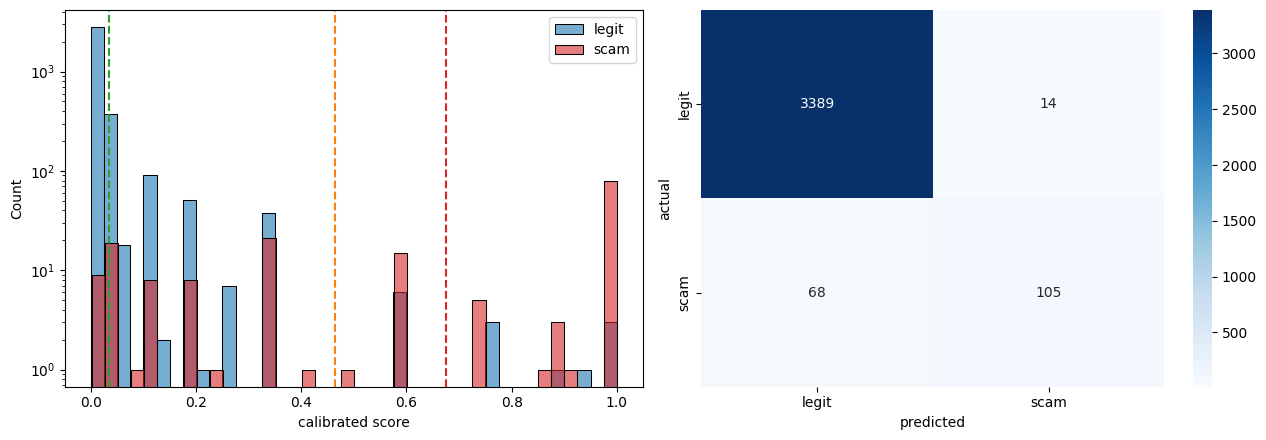

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(test_cal[y_test == 0], bins=40, label="legit", ax=axes[0],
             color="tab:blue", alpha=0.6)
sns.histplot(test_cal[y_test == 1], bins=40, label="scam", ax=axes[0],
             color="tab:red", alpha=0.6)
for t, c in [(SOFT_FLAG, "tab:green"), (HARD_FLAG, "tab:orange"), (AUTO_REMOVE, "tab:red")]:
    axes[0].axvline(t, ls="--", color=c)
axes[0].set_yscale("log")
axes[0].set_xlabel("calibrated score")
axes[0].legend()

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["legit", "scam"], yticklabels=["legit", "scam"], ax=axes[1])
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("actual")

plt.tight_layout()
plt.show()

## **Cross Validation**

In [ ]:
cv_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=300, max_depth=25, min_samples_split=5, min_samples_leaf=2,
        max_features="sqrt", random_state=42, n_jobs=-1)),
])
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_ap = cross_val_score(cv_pipe, X_train_s, y_train, cv=folds,
                        scoring="average_precision", n_jobs=-1)
cv_auc = cross_val_score(cv_pipe, X_train_s, y_train, cv=folds,
                         scoring="roc_auc", n_jobs=-1)

print(f"CV avg precision : {cv_ap.mean():.4f} (+/- {cv_ap.std()*2:.4f})")
print(f"test avg precision : {ap:.4f}")
print()
print(f"CV AUC-ROC       : {cv_auc.mean():.4f} (+/- {cv_auc.std()*2:.4f})")
print(f"test AUC-ROC       : {auc:.4f}")

CV avg precision : 0.7170 (+/- 0.0492)
test avg precision : 0.7587

CV AUC-ROC       : 0.9325 (+/- 0.0166)
test AUC-ROC       : 0.9634


## **Sanity Check**

In [ ]:
SAMPLES = [
    ("legit", "Backend Developer for Internal Dashboard",
     "We need an experienced backend developer to build REST APIs for our internal analytics "
     "dashboard. Must know Python, FastAPI, and PostgreSQL. Fixed budget, 4 weeks."),
    ("legit", "Senior Product Designer",
     "Join our team to design user flows and high fidelity mockups for a fintech product. "
     "Figma experience required. Competitive salary, full time position in Jakarta."),
    ("legit", "Freelance Content Writer for SaaS Blog",
     "Write two long form articles per month about developer tooling. Portfolio required. "
     "Paid per article, remote, flexible deadlines."),
    ("scam", "URGENT - Easy Work From Home - Earn $5000 Weekly!",
     "Work from home and earn guaranteed income immediately! No experience needed, anyone can "
     "apply, easy work for beginners. To secure your spot today, send a $50 registration fee "
     "via Western Union or Bitcoin. Limited time offer, act now before spots run out!"),
    ("scam", "Payment Processing Agent - Immediate Start - No Experience",
     "Work from home as a payment processing agent. Receive funds into your personal bank "
     "account and forward via wire transfer or bitcoin. Keep 10% commission. Earn easy money "
     "with no experience needed. Urgent, start immediately. Deposit required to activate."),
    ("scam", "Crypto Investment Manager - Guaranteed Returns - Hurry",
     "Investment required before joining. Send bitcoin deposit to secure your position. "
     "100% profit guaranteed, get rich quick, unlimited earning potential. Anyone can apply, "
     "no experience needed. Act now! Limited time. Work from home, apply now for free."),
]

print(f"{'label':<7}{'score':>8}  {'verdict':<12} title")
print("-" * 78)
for label, title, desc in SAMPLES:
    row = scam_features.build_row(title, desc, sbert_model).reshape(1, -1)
    score = float(predict_calibrated(scaler.transform(row))[0])
    if score >= AUTO_REMOVE:  verdict = "auto-remove"
    elif score >= HARD_FLAG:  verdict = "auto-close"
    elif score >= SOFT_FLAG:  verdict = "review"
    else:                     verdict = "pass"
    print(f"{label:<7}{score:>8.4f}  {verdict:<12} {title[:44]}")

label     score  verdict      title
------------------------------------------------------------------------------
legit    0.0033  pass         Backend Developer for Internal Dashboard
legit    0.0016  pass         Senior Product Designer
legit    0.0113  pass         Freelance Content Writer for SaaS Blog
scam     0.1818  review       URGENT - Easy Work From Home - Earn $5000 We
scam     0.0500  review       Payment Processing Agent - Immediate Start -
scam     0.1163  review       Crypto Investment Manager - Guaranteed Retur


## **Save Model**

In [ ]:
metrics = {
    "model_name": "Sentence-BERT + Random Forest (calibrated)",
    "model_type": "sbert_rf_calibrated",
    "accuracy": float(accuracy),
    "balanced_accuracy": float(balanced_acc),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "auc_roc": float(auc),
    "average_precision": float(ap),
    "matthews_corrcoef": float(mcc),
    "cohen_kappa": float(kappa),
    "specificity": float(specificity),
    "true_negatives": int(tn), "false_positives": int(fp),
    "false_negatives": int(fn), "true_positives": int(tp),
    "false_positive_rate": float(fpr), "false_negative_rate": float(fnr),
    "cv_average_precision_mean": float(cv_ap.mean()),
    "cv_average_precision_std": float(cv_ap.std()),
    "cv_auc_roc_mean": float(cv_auc.mean()),
    "cv_auc_roc_std": float(cv_auc.std()),
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "train_samples": int(len(y_train)),
    "train_samples_after_smote": int(len(y_train_bal)),
    "val_samples": int(len(y_val)),
    "test_samples": int(len(y_test)),
    "feature_count": int(X.shape[1]),
    "sbert_model": sbert_model_name,
    "engineered_features": scam_features.FEATURE_NAMES,
    "text_fields": ["title", "description"],
    "calibration": "isotonic, fitted on held-out validation split",
    "calibrator_levels": int(len(levels)),
    "sklearn_version": sklearn.__version__,
    "thresholds": {
        "SOFT_FLAG": SOFT_FLAG,
        "HARD_FLAG": HARD_FLAG,
        "AUTO_REMOVE": AUTO_REMOVE,
    },
    "threshold_flag_rates": {
        name: float((val_cal >= t).mean())
        for name, t in [("SOFT_FLAG", SOFT_FLAG), ("HARD_FLAG", HARD_FLAG),
                        ("AUTO_REMOVE", AUTO_REMOVE)]
    },
}

joblib.dump(rf_model,   f"{OUT_DIR}/sbert_rf_model.pkl")
joblib.dump(scaler,     f"{OUT_DIR}/scaler.pkl")
joblib.dump(calibrator, f"{OUT_DIR}/calibrator.pkl")

with open(f"{OUT_DIR}/sbert_encoder_name.txt", "w") as f:
    f.write(sbert_model_name)
with open(f"{OUT_DIR}/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)
with open(f"{OUT_DIR}/thresholds.json", "w") as f:
    json.dump(metrics["thresholds"], f, indent=4)
with open(f"{OUT_DIR}/requirements-lock.txt", "w") as f:
    f.write(f"scikit-learn=={sklearn.__version__}\n")

print(json.dumps(metrics["thresholds"], indent=2))
print(json.dumps(metrics["threshold_flag_rates"], indent=2))
print(sorted(os.listdir(OUT_DIR)))

{
  "SOFT_FLAG": 0.0353,
  "HARD_FLAG": 0.4633,
  "AUTO_REMOVE": 0.675
}
{
  "SOFT_FLAG": 0.10822147651006711,
  "HARD_FLAG": 0.032997762863534674,
  "AUTO_REMOVE": 0.027404921700223715
}
['__pycache__', 'calibrator.pkl', 'model_metrics.json', 'requirements-lock.txt', 'sbert_encoder_name.txt', 'sbert_rf_model.pkl', 'scaler.pkl', 'scam_features.py', 'thresholds.json']


In [ ]:
serving_src = r'''
import json
import os
from functools import lru_cache
from typing import Dict

import joblib

import scam_features

_MODEL_DIR = os.path.dirname(__file__)


@lru_cache(maxsize=1)
def _load():
    from sentence_transformers import SentenceTransformer
    with open(os.path.join(_MODEL_DIR, "sbert_encoder_name.txt")) as fh:
        encoder = SentenceTransformer(fh.read().strip())
    rf = joblib.load(os.path.join(_MODEL_DIR, "sbert_rf_model.pkl"))
    scaler = joblib.load(os.path.join(_MODEL_DIR, "scaler.pkl"))
    calibrator = joblib.load(os.path.join(_MODEL_DIR, "calibrator.pkl"))
    with open(os.path.join(_MODEL_DIR, "thresholds.json")) as fh:
        thresholds = json.load(fh)
    return encoder, rf, scaler, calibrator, thresholds


def predict_scam(title: str, description: str) -> Dict:
    encoder, rf, scaler, calibrator, th = _load()

    row = scam_features.build_row(title, description, encoder).reshape(1, -1)
    raw = rf.predict_proba(scaler.transform(row))[0][1]
    score = float(calibrator.predict([raw])[0])

    return {
        "scam_probability": round(score, 4),
        "is_scam":          score >= th["HARD_FLAG"],
        "needs_review":     score >= th["SOFT_FLAG"],
        "auto_removable":   score >= th["AUTO_REMOVE"],
        "model_used": "sbert_rf_calibrated",
    }
'''

with open(f"{OUT_DIR}/serving_reference.py", "w") as f:
    f.write(serving_src)

print("serving_reference.py written")

serving_reference.py written


In [ ]:
shutil.make_archive("model2_sbert_rf_complete", "zip", OUT_DIR)
print("bundle:", round(os.path.getsize("model2_sbert_rf_complete.zip") / 1e6, 2), "MB")

try:
    from google.colab import files
    files.download("model2_sbert_rf_complete.zip")
except ImportError:
    pass

bundle: 7.32 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>